# CIFAR-10 class indexlari

- 0: airplane
- 1: automobile (car)
- 2: bird
- 3: cat
- 4: deer
- 5: dog
- 6: frog
- 7: horse
- 8: ship
- 9: truck

In [4]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import datasets, transforms

# CONFIG
DATA_DIR = Path("../data/raw")
BATCH_SIZE = 64
EPOCHS = 3
LEARNING_RATE = 0.001
IMAGE_SIZE = 64
RANDOM_SEED = 42
CLASS_NAMES = ["ship", "truck"]
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_DIR.mkdir(parents=True, exist_ok=True)

# SEED
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

print("Device:", DEVICE)

Device: cpu


In [5]:
SHIP_CLASS_INDEX = 8
TRUCK_CLASS_INDEX = 9

In [6]:
def filter_ship_truck(cifar_dataset):
    images = []
    labels = []

    for image_array, label in zip(cifar_dataset.data, cifar_dataset.targets):
        if label == SHIP_CLASS_INDEX:
            images.append(Image.fromarray(image_array))
            labels.append(0)  # ship
        elif label == TRUCK_CLASS_INDEX:
            images.append(Image.fromarray(image_array))
            labels.append(1)  # truck

    return images, labels

In [7]:
train_cifar = datasets.CIFAR10(root=str(DATA_DIR), train=True, download=True)
test_cifar = datasets.CIFAR10(root=str(DATA_DIR), train=False, download=True)

train_images, train_labels = filter_ship_truck(train_cifar)
test_images, test_labels = filter_ship_truck(test_cifar)

print("Filtered train images:", len(train_images))
print("Filtered test images:", len(test_images))

c:\Users\Rasulbekk\Desktop\Practise\venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Filtered train images: 10000
Filtered test images: 2000


In [8]:
class ShipTruckDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        image = self.images[index]
        label = self.labels[index]

        if self.transform:
            image = self.transform(image)

        return image, label

In [9]:
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5),
                         (0.5, 0.5, 0.5)),
])

In [10]:
full_train_dataset = ShipTruckDataset(train_images, train_labels, transform)
test_dataset = ShipTruckDataset(test_images, test_labels, transform)

train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

generator = torch.Generator().manual_seed(RANDOM_SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 8000
Val: 2000
Test: 2000


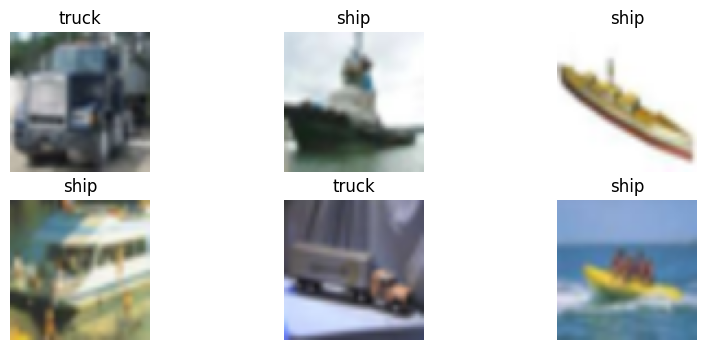

In [11]:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 4))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5
    img = img.clip(0, 1)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")

plt.show()

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [13]:
def run_one_epoch(model, dataloader, criterion, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_training):
        for images, labels in dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            if is_training:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_training:
                loss.backward()
                optimizer.step()

            preds = torch.argmax(outputs, dim=1)

            total_loss += loss.item() * labels.size(0)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return total_loss / total, 100 * correct / total

In [14]:
for epoch in range(EPOCHS):
    train_loss, train_acc = run_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, criterion)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")

Epoch 1/3
Train Loss: 0.4262 | Acc: 79.54%
Val Loss: 0.3348 | Acc: 86.70%
Epoch 2/3
Train Loss: 0.2832 | Acc: 88.09%
Val Loss: 0.2322 | Acc: 90.95%
Epoch 3/3
Train Loss: 0.2410 | Acc: 89.89%
Val Loss: 0.2229 | Acc: 90.95%


In [15]:
test_loss, test_acc = run_one_epoch(model, test_loader, criterion)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_acc, 2), "%")

Test Loss: 0.2484
Test Accuracy: 89.8 %


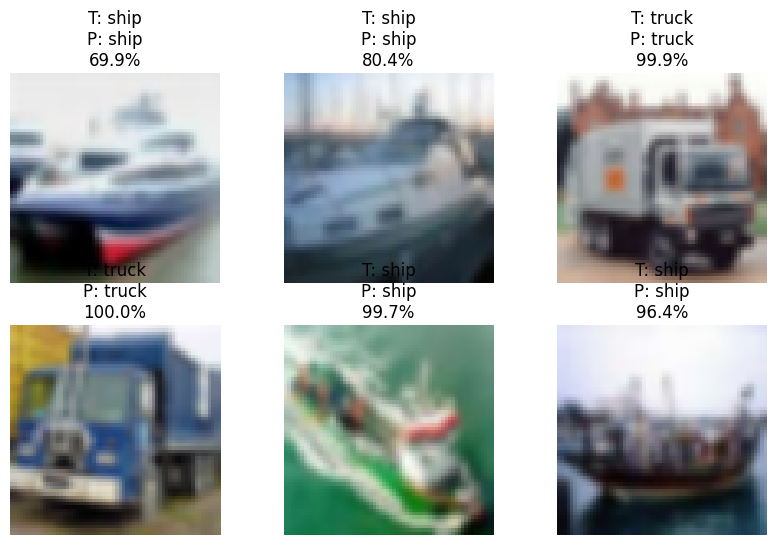

In [16]:
images, labels = next(iter(test_loader))

with torch.no_grad():
    outputs = model(images.to(DEVICE))
    probs = torch.softmax(outputs, dim=1)
    conf, preds = torch.max(probs, dim=1)

plt.figure(figsize=(10, 6))
for i in range(6):
    img = images[i].permute(1, 2, 0).numpy()
    img = (img * 0.5) + 0.5

    title = f"T: {CLASS_NAMES[labels[i]]}\nP: {CLASS_NAMES[preds[i]]}\n{conf[i]*100:.1f}%"

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis("off")

plt.show()

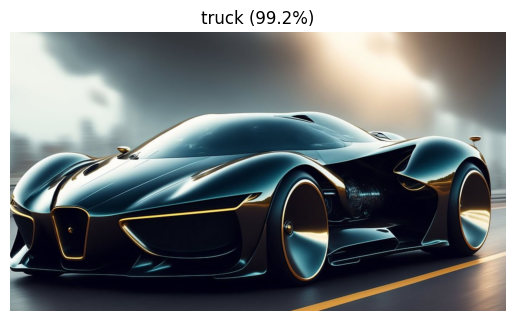

In [17]:
image_name = "car.jpg"
image_path = Path(image_name)

if image_path.exists():
    image = Image.open(image_path).convert("RGB")

    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        prob = torch.softmax(output, dim=1)
        conf, pred = torch.max(prob, dim=1)

    plt.imshow(image)
    plt.title(f"{CLASS_NAMES[pred.item()]} ({conf.item()*100:.1f}%)")
    plt.axis("off")
    plt.show()
else:
    print("Image not found!")